# Adult Income Classification
**Link:** https://archive.ics.uci.edu/dataset/2/adult

## Descripción del proyecto
Este proyecto tiene como objetivo predecir si una persona percibe ingresos anuales superiores a 50K a partir de variables sociodemográficas y laborales del dataset **Adult Census Income**.

Se trata de un problema de **clasificación binaria**, en el que la variable objetivo indica si el ingreso anual es `<=50K` o `>50K`.

## Objetivos
- Explorar el comportamiento de las variables numéricas y categóricas.
- Identificar patrones asociados a ingresos superiores a 50K.
- Construir y comparar modelos de machine learning.
- Evaluar cuáles variables aportan mayor valor predictivo.

## Tecnologías utilizadas
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- imbalanced-learn
- missingno


#### 1.- Librerías utilizadas

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Carga de datos

Se carga el dataset original y se revisa su estructura general.

#### 2.- Carga de datos

In [52]:
# =========================================
# 2. CARGA DE DATOS
# =========================================
df = pd.read_csv("train_adultos.csv", skipinitialspace=True, sep=",") 

display(df.head())
print("Dimensión del dataset:", df.shape)


,age,work-class,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Dimensión del dataset: (32561, 15)


## 2. Revisión inicial

En esta sección se revisan:
- tipos de datos
- variables disponibles
- forma inicial de la variable objetivo

In [53]:
# =========================================
# 3. REVISION INICIAL
# =========================================
display(df.dtypes.to_frame("dtype"))
print("Valores únicos de income:", df["income"].unique())


,dtype
age,int64
work-class,str
fnlwgt,int64
education,str
education-num,int64
marital-status,str
occupation,str
relationship,str
race,str
sex,str


Valores únicos de income: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


## 3. Limpieza básica

Se realiza una limpieza inicial de los datos:
- reemplazo de valores faltantes representados como `?`
- limpieza de espacios en columnas de texto
- transformación de la variable objetivo a formato numérico

In [54]:
# =========================================
# 4. LIMPIEZA BASICA
# =========================================
df = df.replace("?", np.nan)

for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].str.strip() 
#Usamos str.strip() para eliminar espacios en blanco al inicio y al final de las cadenas de texto

df["income"] = df["income"].map({"<=50K": 0, ">50K": 1}).astype(int)

display(df.head())
display(df.info())


,age,work-class,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   work-class      30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  31978 non-null  str  
 14  income          32561 non-null  int64
dtypes: int64(7), str(8)
memory usage: 3.7 MB


None

## 4. Análisis de valores faltantes

Se analiza la presencia de nulos y su posible relación entre variables.


##### 4.1.- Valores nulos

In [56]:
#Visualizar las variables con datos nulos
df.isna().sum()

age                  0
work-class        1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [57]:
print(round((df['work-class'].isna().mean()) * 100,3))
print(round((df['occupation'].isna().mean()) * 100,3))
print(round((df['native-country'].isna().mean()) * 100,3))

5.639
5.66
1.79


Existen valores nules en las variables: Work-class, Occupatión y Native Country pero que no representán más del 6% del total de datos, igualmente analizaremos los campos nulos por si existe alguna relación entre las variables.

<Axes: >

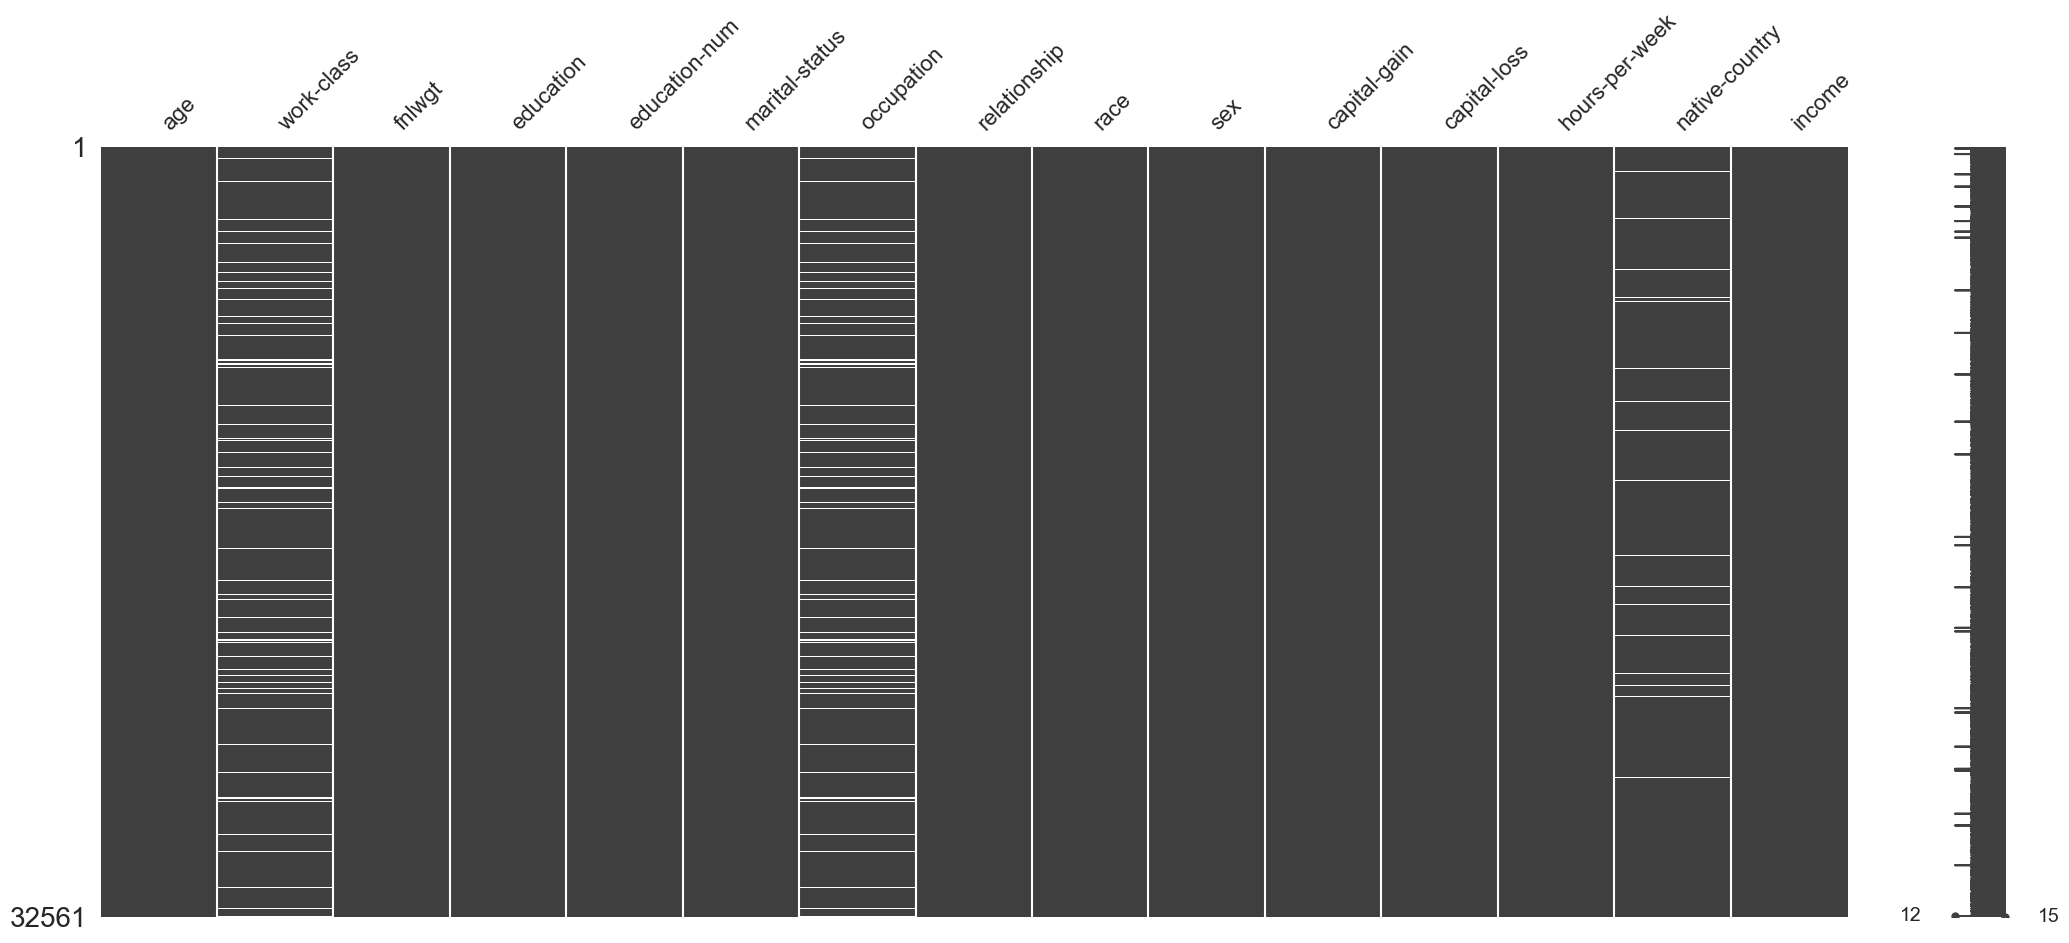

In [58]:
import missingno as msno
msno.matrix(df)

Podemos ver que en los casos donde figura un valor nulo en "Work Class", también se da para "Occupation", por lo que nos dice que la persona encuestada no tiene ocupación ni trabajo actual; sin embargo, para estar seguro de ello se procede con la correlación de los nulos de las dos variables.

El campo de "Native Country" sí parece ser un campo aislado.

In [59]:
(df[(df['work-class'].isnull()) & (df['occupation'].isnull())].shape[0] / len(df))*100

5.638647461687294

In [60]:
df[["work-class","occupation"]].isnull().corr()

,work-class,occupation
work-class,1.0000,0.9980
occupation,0.9980,1.0000


Análisis de valores nulos

- Observamos que del total de registros (32561), el 5.64% presentan valores nulos simultáneamente en 'work-class' y 'occupation'.

- Además se identificó que las variables `work-class` y `occupation` presentan valores faltantes altamente correlacionados (~0.998), lo que sugiere que la ausencia de información ocurre de manera conjunta.

Esto indica que ambos atributos comparten información similar en términos de datos faltantes.

## 5. Distribución de la variable objetivo

Se analiza la proporción de clases para verificar si existe desbalance.

C:\Users\ricar\AppData\Local\Temp\ipykernel_15872\396802740.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["<=50K", ">50K"])


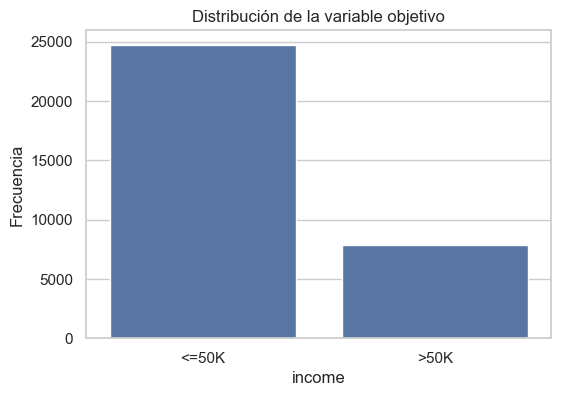

,count
income,
<=50K,24720
>50K,7841


Proporción de clase positiva (>50K): 24.08 %


In [68]:
# =========================================
# 6. VARIABLE OBJETIVO
# =========================================
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="income", ax=ax)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("income")
ax.set_ylabel("Frecuencia")
ax.set_xticklabels(["<=50K", ">50K"])
plt.show()

target_counts = df["income"].value_counts().rename(index={0: "<=50K", 1: ">50K"})
display(target_counts.to_frame("count"))

print("Proporción de clase positiva (>50K):", round(df["income"].mean() * 100, 2), "%")

El dataset presenta un desbalance moderado: la clase `<=50K` es mayoritaria, mientras que la clase `>50K` representa aproximadamente una cuarta parte del total de registros.

Por ello, en la etapa de modelado se dará especial atención a métricas como `recall`, `F1-score` y `ROC-AUC`, y no solo a la exactitud global.

## 6. Análisis de variables numéricas

Se revisan estadísticas descriptivas, distribuciones y correlaciones entre variables numéricas.

In [69]:
# =========================================
# 7. ANALISIS NUMERICO
# =========================================
numeric_cols = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

df[numeric_cols + ["income"]].describe()

,age,education-num,capital-gain,capital-loss,hours-per-week,income
count,"32,561.0000","32,561.0000","32,561.0000","32,561.0000","32,561.0000","32,561.0000"
mean,38.5816,10.0807,"1,077.6488",87.3038,40.4375,0.2408
std,13.6404,2.5727,"7,385.2921",402.9602,12.3474,0.4276
min,17.0000,1.0000,0.0000,0.0000,1.0000,0.0000
25%,28.0000,9.0000,0.0000,0.0000,40.0000,0.0000
50%,37.0000,10.0000,0.0000,0.0000,40.0000,0.0000
75%,48.0000,12.0000,0.0000,0.0000,45.0000,0.0000
max,90.0000,16.0000,"99,999.0000","4,356.0000",99.0000,1.0000


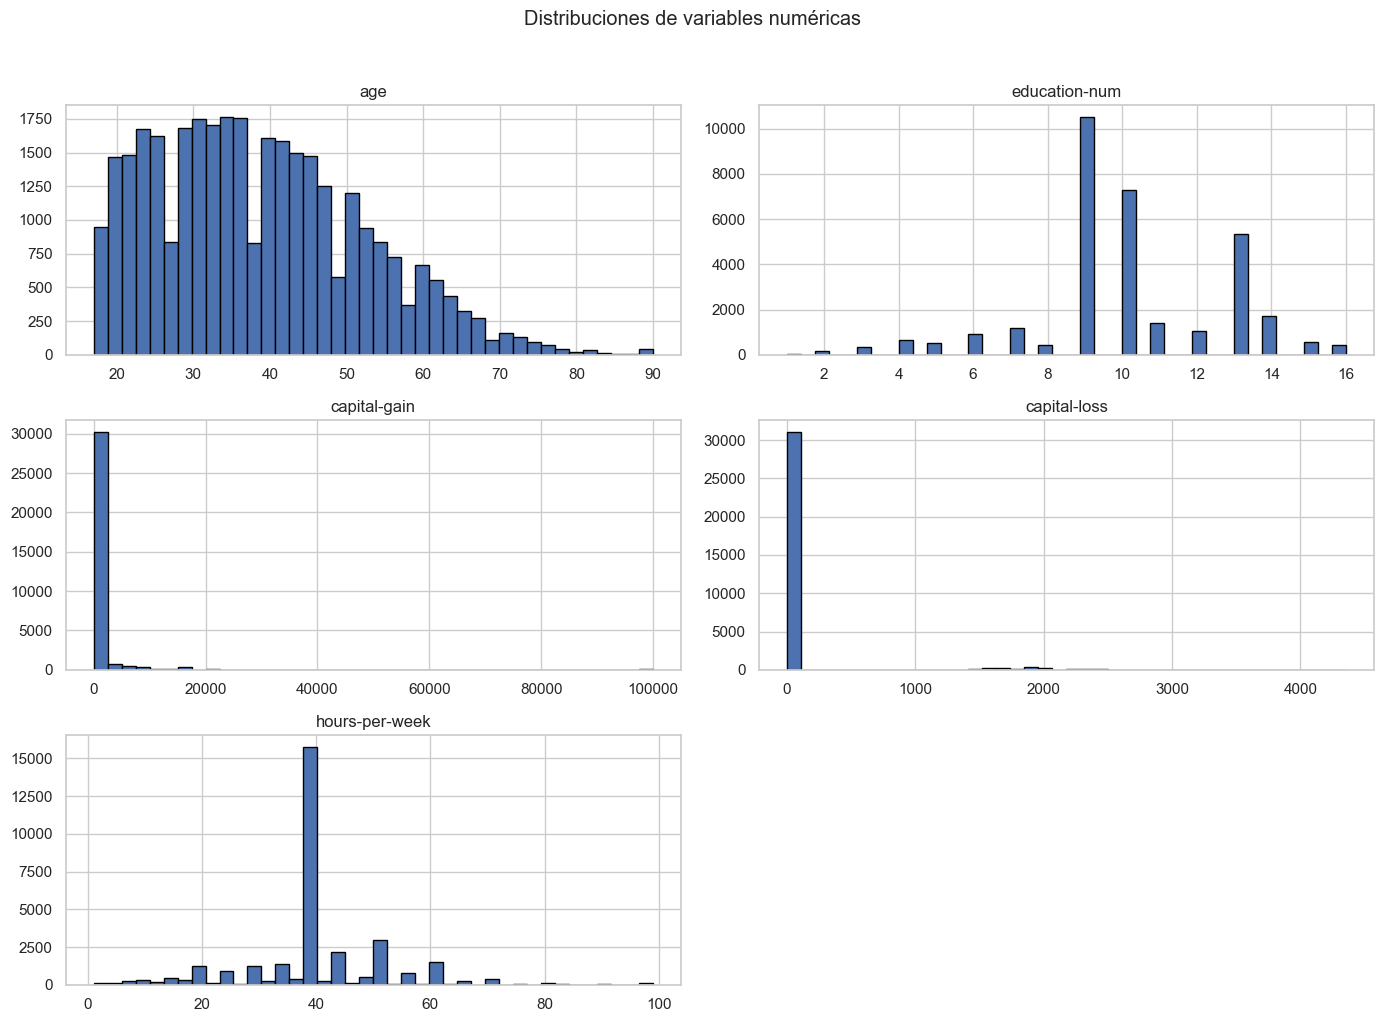

In [71]:
fig=df[numeric_cols].hist(bins=40, figsize=(14, 10), color="#4C72B0", edgecolor="black")
plt.suptitle("Distribuciones de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

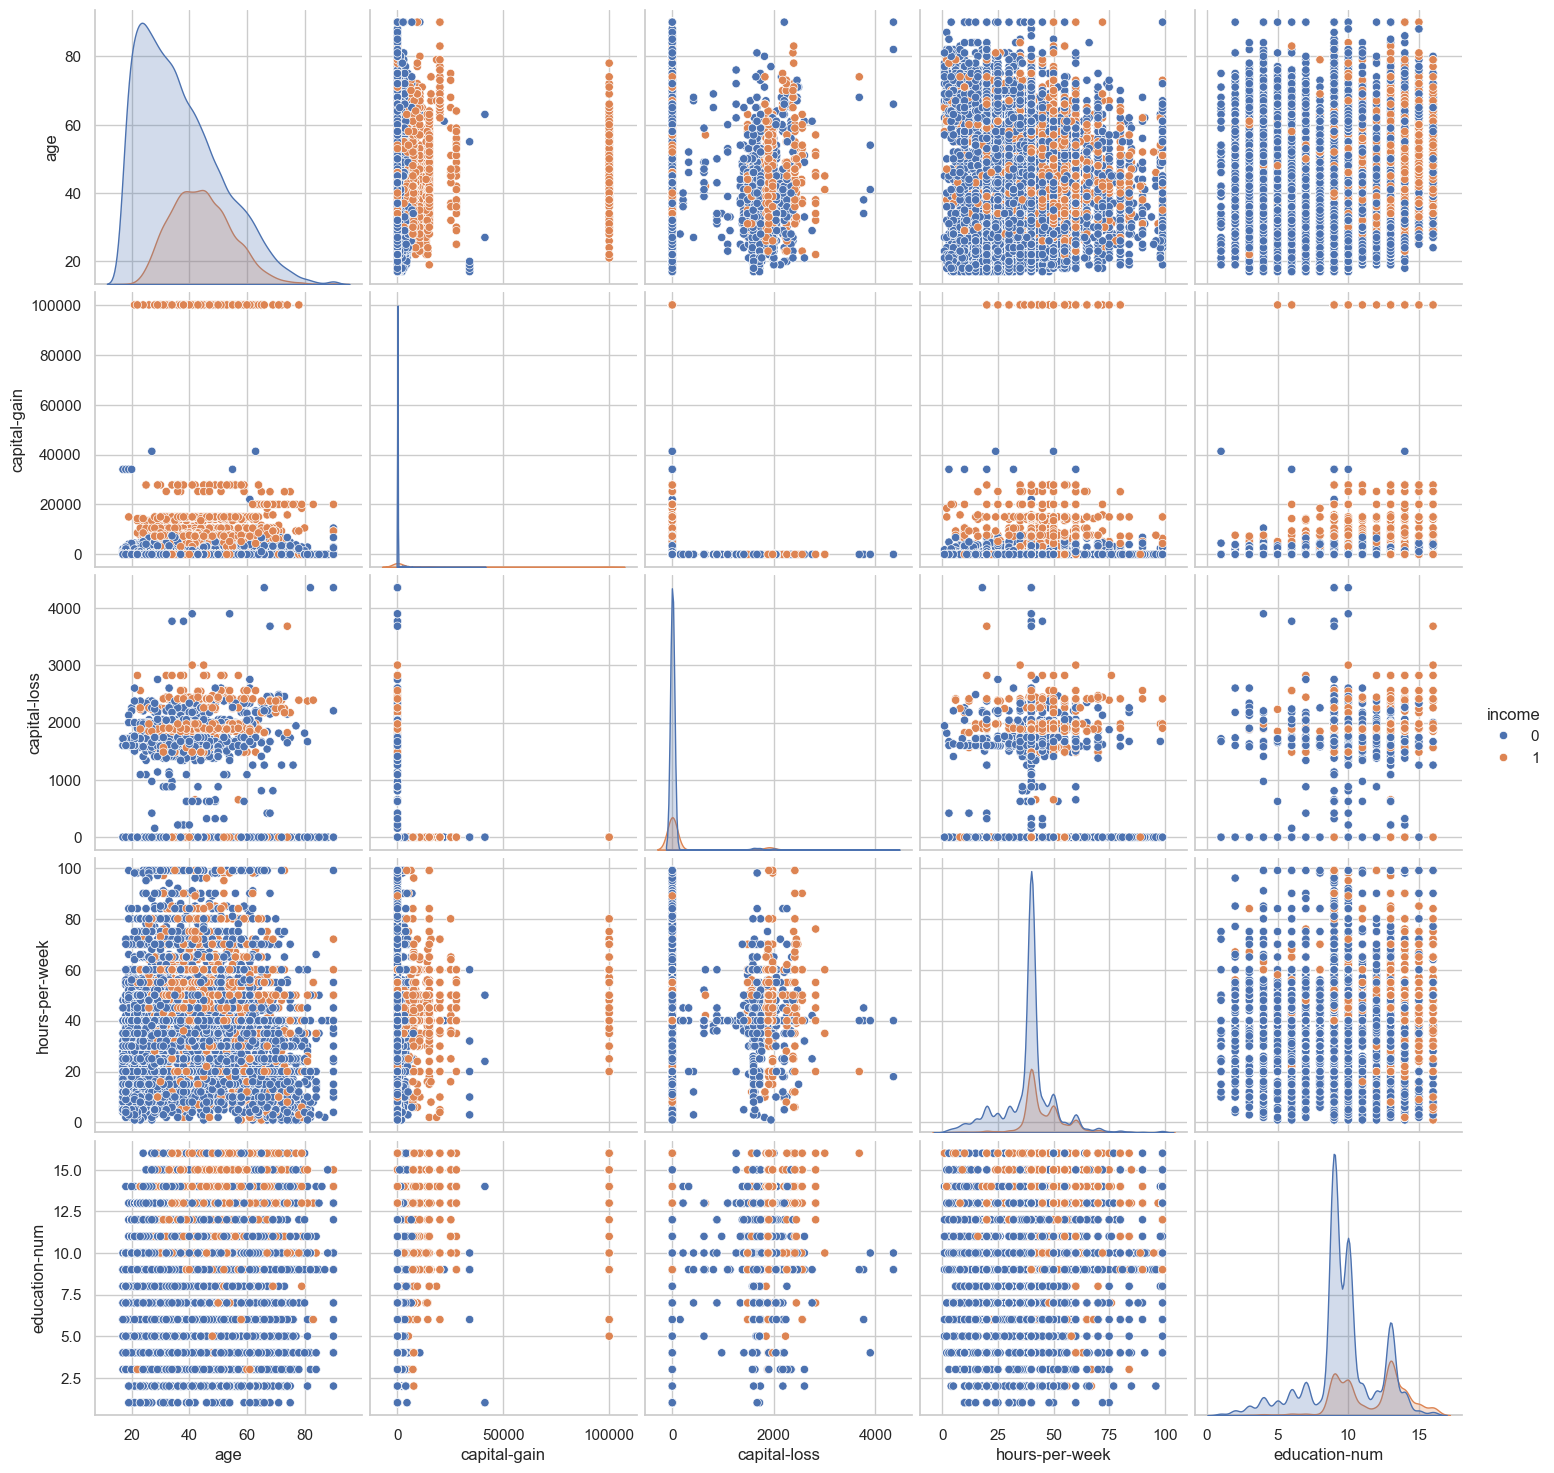

In [72]:
Variables = ['age', 'capital-gain', 'capital-loss', 'hours-per-week','education-num','income']
sns.pairplot(df[Variables], height=3, diag_kind = 'kde', hue='income')

Cruzamos las variables numéricas entre ellas y adiconalmente agregamos el Target para conocer la distribución y comenzar a generar hipótesis de variables que discriminan mejor a ambos grupos (Mayor y menor sueldo a 50K).

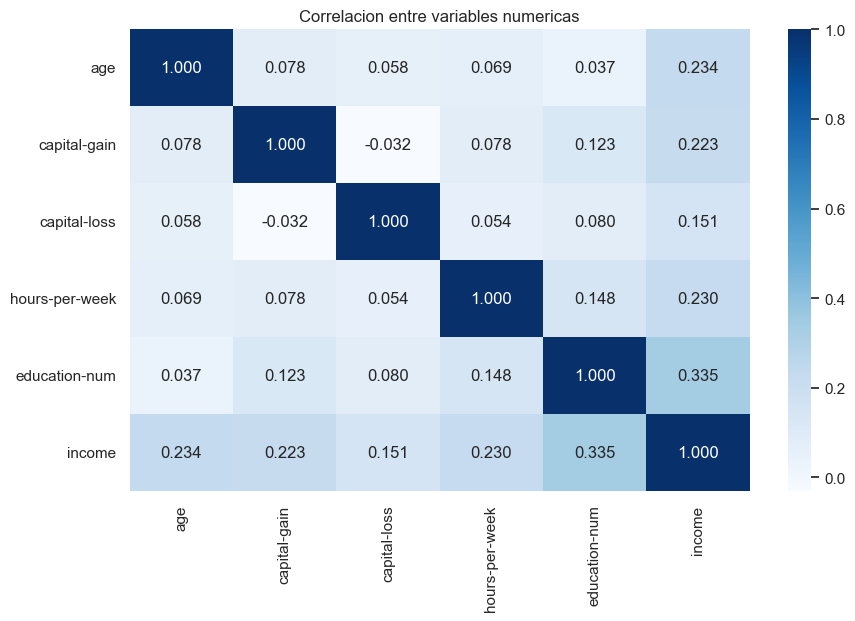

income           1.0000
education-num    0.3352
age              0.2340
hours-per-week   0.2297
capital-gain     0.2233
capital-loss     0.1505
Name: income, dtype: float64


In [73]:
num_cols = df[Variables].corr()

plt.figure(figsize=(10,6))
sns.heatmap(num_cols, annot=True, cmap="Blues", fmt=".3f")
plt.title("Correlacion entre variables numericas")
plt.show()

print(num_cols["income"].sort_values(ascending=False))

### Hallazgos numéricos

Entre las variables numéricas, `education-num` presenta la mayor asociación lineal con la variable objetivo, seguida por `age`, `hours-per-week`, `capital-gain` y `capital-loss`.

También se observa que `capital-gain` y `capital-loss` presentan distribuciones altamente sesgadas, con gran presencia de valores cercanos a cero y algunos valores extremos.

## 7. Análisis de variables categóricas

Se revisa la distribución de las variables cualitativas y su relación con la proporción de ingresos superiores a 50K.


In [22]:
categorical_attributes = df.select_dtypes(include=['object'])

C:\Users\ricar\AppData\Local\Temp\ipykernel_15872\1348925879.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_attributes = df.select_dtypes(include=['object'])


In [23]:
categorical_attributes.dtypes

work-class        str
education         str
marital-status    str
occupation        str
relationship      str
race              str
sex               str
native-country    str
dtype: object

###### 4.4.1.- Work Class (Tipo de Trabajo)

work-class
Private             0.738682
Self-emp-not-inc    0.082701
Local-gov           0.068120
State-gov           0.042246
Self-emp-inc        0.036322
Federal-gov         0.031245
Without-pay         0.000456
Never-worked        0.000228
Name: proportion, dtype: float64

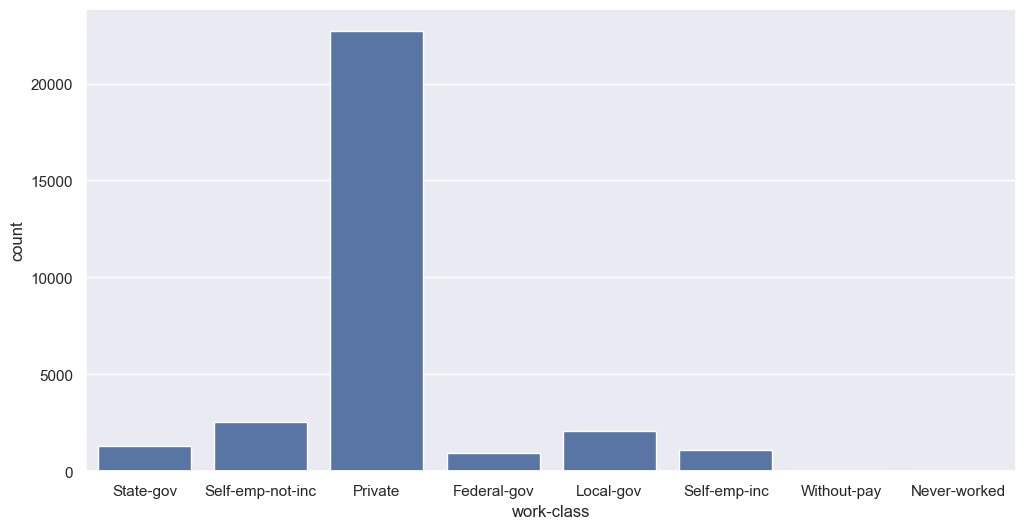

In [24]:
#Analisis Univeriado
plt.figure(figsize=(12,6))
sns.countplot(data = categorical_attributes, x = "work-class")
df['work-class'].value_counts(normalize=True)

Insight

Se observa que la mayoría de individuos pertenece a la categoría "Private", lo que refleja la distribución real del mercado laboral.

Además, ciertas categorías como "Self-emp-not-inc" presentan mayor proporción de ingresos superiores a 50K.


In [25]:
pd.crosstab(df['work-class'], df['income'], normalize='index')

income,0,1
work-class,,
Federal-gov,0.613542,0.386458
Local-gov,0.705208,0.294792
Never-worked,1.000000,0.000000
Private,0.781327,0.218673
Self-emp-inc,0.442652,0.557348
Self-emp-not-inc,0.715073,0.284927
State-gov,0.728043,0.271957
Without-pay,1.000000,0.000000


In [26]:
#sns.factorplot('income',data=df,hue='work-class',kind="count")
df[['work-class', 'income']].groupby(['work-class'], as_index=False).agg(['count','sum','mean'])

work-class income                
                     count   sum      mean
0       Federal-gov    960   371  0.386458
1         Local-gov   2093   617  0.294792
2      Never-worked      7     0  0.000000
3           Private  22696  4963  0.218673
4      Self-emp-inc   1116   622  0.557348
5  Self-emp-not-inc   2541   724  0.284927
6         State-gov   1298   353  0.271957
7       Without-pay     14     0  0.000000

Los segmentos de "Work-Class" con mayor proporción de salarios mayor a 50K (1) es en "Self-emp-inc" y "Federal-gov".

###### 4.4.2.- Education (Educación)

In [27]:
df['education'].value_counts(1)

education
HS-grad         0.322502
Some-college    0.223918
Bachelors       0.164461
Masters         0.052916
Assoc-voc       0.042443
11th            0.036086
Assoc-acdm      0.032769
10th            0.028654
7th-8th         0.019840
Prof-school     0.017690
9th             0.015786
12th            0.013298
Doctorate       0.012684
5th-6th         0.010227
1st-4th         0.005160
Preschool       0.001566
Name: proportion, dtype: float64

El nivel de educación "HS-grad" cuenta con el 32% de observaciones, seguido con "Some-Collegue" con 22% aprox.

In [ ]:
df[['education', 'income']].groupby(['education'], as_index=False).agg(['count','sum','mean']) #para 

education income                
                  count   sum      mean
0           10th    933    62  0.066452
1           11th   1175    60  0.051064
2           12th    433    33  0.076212
3        1st-4th    168     6  0.035714
4        5th-6th    333    16  0.048048
5        7th-8th    646    40  0.061920
6            9th    514    27  0.052529
7     Assoc-acdm   1067   265  0.248360
8      Assoc-voc   1382   361  0.261216
9      Bachelors   5355  2221  0.414753
10     Doctorate    413   306  0.740920
11       HS-grad  10501  1675  0.159509
12       Masters   1723   959  0.556587
13     Preschool     51     0  0.000000
14   Prof-school    576   423  0.734375
15  Some-college   7291  1387  0.190235

Los niveles de "Education" con mayor proporción de salarios mayor a 50K (1) son "Doctorate", "Prof-school", "Masters" y "Bachelors".

###### 4.4.3.- Marital Status

In [29]:
df['marital-status'].value_counts(1)

marital-status
Married-civ-spouse       0.459937
Never-married            0.328092
Divorced                 0.136452
Separated                0.031479
Widowed                  0.030497
Married-spouse-absent    0.012837
Married-AF-spouse        0.000706
Name: proportion, dtype: float64

El nivel de marital status "Married-civ-spouse" cuenta con el 46% de observaciones, seguido con "Never-married" con 33% aprox.

In [30]:
df[['marital-status', 'income']].groupby(['marital-status'], as_index=False).agg(['count','sum','mean'])

marital-status income                
                          count   sum      mean
0               Divorced   4443   463  0.104209
1      Married-AF-spouse     23    10  0.434783
2     Married-civ-spouse  14976  6692  0.446848
3  Married-spouse-absent    418    34  0.081340
4          Never-married  10683   491  0.045961
5              Separated   1025    66  0.064390
6                Widowed    993    85  0.085599

Los niveles de "marital-status" con mayor proporción de salarios mayor a 50K (1) es en "Married-AF-spouse" y "Married-civ-spouse".

###### 4.4.4.- Occupation

In [31]:
df['occupation'].value_counts(1)

occupation
Prof-specialty       0.134774
Craft-repair         0.133440
Exec-managerial      0.132365
Adm-clerical         0.122729
Sales                0.118823
Other-service        0.107266
Machine-op-inspct    0.065174
Transport-moving     0.051989
Handlers-cleaners    0.044599
Farming-fishing      0.032359
Tech-support         0.030210
Protective-serv      0.021128
Priv-house-serv      0.004851
Armed-Forces         0.000293
Name: proportion, dtype: float64

Los niveles de occupation Prof-specialty, Craft-repair, Exec-managerial, Adm-clerical, Sales y Other-service tienen entre un 10 y 13% de observaciones, mientras que los restantes tienen de 6% a menos.

In [32]:
df[['occupation', 'income']].groupby(['occupation'], as_index=False).agg(['count','sum','mean'])

occupation income                
                       count   sum      mean
0        Adm-clerical   3770   507  0.134483
1        Armed-Forces      9     1  0.111111
2        Craft-repair   4099   929  0.226641
3     Exec-managerial   4066  1968  0.484014
4     Farming-fishing    994   115  0.115694
5   Handlers-cleaners   1370    86  0.062774
6   Machine-op-inspct   2002   250  0.124875
7       Other-service   3295   137  0.041578
8     Priv-house-serv    149     1  0.006711
9      Prof-specialty   4140  1859  0.449034
10    Protective-serv    649   211  0.325116
11              Sales   3650   983  0.269315
12       Tech-support    928   283  0.304957
13   Transport-moving   1597   320  0.200376

Los niveles de "occupation" con mayor proporción de salarios mayor a 50K (1) es en "Exec-managerial" y "Prof-specialty".

###### 4.4.5.- Relationship

In [33]:
df['relationship'].value_counts(1)

relationship
Husband           0.405178
Not-in-family     0.255060
Own-child         0.155646
Unmarried         0.105832
Wife              0.048156
Other-relative    0.030128
Name: proportion, dtype: float64

El nivel de relationship "Husband" cuenta con el 41% de observaciones, seguido con "Not-in-family" con 26% aprox.

In [34]:
df[['relationship', 'income']].groupby(['relationship'], as_index=False).agg(['count','sum','mean'])

relationship income                
                   count   sum      mean
0         Husband  13193  5918  0.448571
1   Not-in-family   8305   856  0.103070
2  Other-relative    981    37  0.037717
3       Own-child   5068    67  0.013220
4       Unmarried   3446   218  0.063262
5            Wife   1568   745  0.475128

Los niveles de "relationship" con mayor proporción de salarios mayor a 50K (1) es en "Wife" y "Husband".

###### 4.4.6.- Race

In [35]:
df['race'].value_counts(1)

race
White                 0.854274
Black                 0.095943
Asian-Pac-Islander    0.031909
Amer-Indian-Eskimo    0.009551
Other                 0.008323
Name: proportion, dtype: float64

El nivel de race "White" cuenta con el 85% de observaciones.

In [36]:
df[['race', 'income']].groupby(['race'], as_index=False).agg(['count','sum','mean'])

race income                
                       count   sum      mean
0  Amer-Indian-Eskimo    311    36  0.115756
1  Asian-Pac-Islander   1039   276  0.265640
2               Black   3124   387  0.123880
3               Other    271    25  0.092251
4               White  27816  7117  0.255860

Los niveles de "race" con mayor proporción de salarios mayor a 50K (1) es en "White" y "Asian-Pac-Islander".

###### 4.4.6.- Sex

In [37]:
df['sex'].value_counts(1)

sex
Male      0.669205
Female    0.330795
Name: proportion, dtype: float64

El género Masculino cuenta con el 67% de personas, es decir 2 de cada 3 personas son masculinos.

In [38]:
df[['sex', 'income']].groupby(['sex'], as_index=False).agg(['count','sum','mean'])

sex income                
           count   sum      mean
0  Female  10771  1179  0.109461
1    Male  21790  6662  0.305737

El género Masculino tiene mayor proporción de salarios mayor a 50K (1) respecto al género femenino (30% vs 11%).

###### 4.4.7.- native-country

In [39]:
df['native-country'].value_counts(1)

native-country
United-States                 0.912190
Mexico                        0.020108
Philippines                   0.006192
Germany                       0.004284
Canada                        0.003784
Puerto-Rico                   0.003565
El-Salvador                   0.003315
India                         0.003127
Cuba                          0.002971
England                       0.002814
Jamaica                       0.002533
South                         0.002502
China                         0.002345
Italy                         0.002283
Dominican-Republic            0.002189
Vietnam                       0.002095
Guatemala                     0.002001
Japan                         0.001939
Poland                        0.001876
Columbia                      0.001845
Taiwan                        0.001595
Haiti                         0.001376
Iran                          0.001345
Portugal                      0.001157
Nicaragua                     0.001063
Peru      

In [40]:
df[['native-country', 'income']].groupby(['native-country'], as_index=False).agg(['count','sum','mean'])

native-country income                
                                count   sum      mean
0                     Cambodia     19     7  0.368421
1                       Canada    121    39  0.322314
2                        China     75    20  0.266667
3                     Columbia     59     2  0.033898
4                         Cuba     95    25  0.263158
5           Dominican-Republic     70     2  0.028571
6                      Ecuador     28     4  0.142857
7                  El-Salvador    106     9  0.084906
8                      England     90    30  0.333333
9                       France     29    12  0.413793
10                     Germany    137    44  0.321168
11                      Greece     29     8  0.275862
12                   Guatemala     64     3  0.046875
13                       Haiti     44     4  0.090909
14          Holand-Netherlands      1     0  0.000000
15                    Honduras     13     1  0.076923
16                        Hong     20     6  0.300000
17                     Hungary     13     3  0.230769
18                       India    100    40  0.400000
19                        Iran     43    18  0.418605
20                     Ireland     24     5  0.208333
21                       Italy     73    25  0.342466
22                     Jamaica     81    10  0.123457
23                       Japan     62    24  0.387097
24                        Laos     18     2  0.111111
25                      Mexico    643    33  0.051322
26                   Nicaragua     34     2  0.058824
27  Outlying-US(Guam-USVI-etc)     14     0  0.000000
28                        Peru     31     2  0.064516
29                 Philippines    198    61  0.308081
30                      Poland     60    12  0.200000
31                    Portugal     37     4  0.108108
32                 Puerto-Rico    114    12  0.105263
33                    Scotland     12     3  0.250000
34                       South     80    16  0.200000
35                      Taiwan     51    20  0.392157
36                    Thailand     18     3  0.166667
37             Trinadad&Tobago     19     2  0.105263
38               United-States  29170  7171  0.245835
39                     Vietnam     67     5  0.074627
40                  Yugoslavia     16     6  0.375000

### Hallazgos categóricos

En las variables categóricas se observan patrones relevantes:
- niveles educativos altos como `Doctorate`, `Prof-school` y `Masters` muestran mayor proporción de ingresos superiores a 50K
- ocupaciones como `Exec-managerial` y `Prof-specialty` presentan una fuerte relación con la clase positiva
- categorías como `Married-civ-spouse`, `Husband` y `Wife` también muestran una mayor proporción de ingresos altos

En el caso de `native-country`, se debe tener cautela al interpretar categorías con pocos registros, ya que sus proporciones pueden ser inestables.


## 8. Preparación de datos para el modelado

En esta etapa se toman decisiones orientadas a construir un pipeline más robusto y reproducible.

### Decisiones metodológicas
- Se elimina `fnlwgt` del modelado por tratarse de una variable de peso muestral, poco interpretable en este contexto.
- Se elimina `education`, ya que `education-num` representa la misma información en formato ordinal.
- Se agrupan los países menos frecuentes en `native-country` dentro de la categoría `Other`.
- La separación entre entrenamiento y prueba se realiza antes de aprender transformaciones.


#### PREPARACION PARA MODELADO


In [80]:
df_model = df.drop(columns=["fnlwgt", "education"]).copy()

X = df_model.drop(columns="income")
y = df_model["income"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)

X_train = X_train.copy()
X_test = X_test.copy()

top_paises = X_train["native-country"].value_counts(dropna=True).head(5).index.tolist()

def agrupar_paises(series, top_values):
    return series.apply(
        lambda x: x if pd.notna(x) and x in top_values else ("Other" if pd.notna(x) else np.nan) 
    )

X_train["native-country"] = agrupar_paises(X_train["native-country"], top_paises) 
X_test["native-country"] = agrupar_paises(X_test["native-country"], top_paises)

print("Dimensión X_train:", X_train.shape)
print("Dimensión X_test :", X_test.shape)
print("\nTop países conservados:", top_paises)

display(X_train["native-country"].value_counts(dropna=False).to_frame("count"))


Dimensión X_train: (22792, 12)
Dimensión X_test : (9769, 12)

Top países conservados: ['United-States', 'Mexico', 'Philippines', 'Germany', 'Canada']


,count
native-country,
United-States,20405
Other,1191
Mexico,479
NaN,407
Philippines,132
Germany,91
Canada,87


## 9. Preprocesamiento

Se utiliza un `ColumnTransformer` para aplicar transformaciones distintas según el tipo de variable:

- Variables numéricas:
  - imputación por mediana
  - escalado con `MinMaxScaler`

- Variables categóricas:
  - imputación por categoría más frecuente
  - codificación mediante `OneHotEncoder`

El uso de `Pipeline` evita errores manuales y ayuda a prevenir data leakage.

#### Preprocesamiento

In [81]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Variables numéricas: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Variables categóricas: ['work-class', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## 10. Modelado

Se comparan tres modelos de clasificación:
- XGBoost
- Random Forest
- Decision Tree

Además, se utiliza `SMOTE` dentro del pipeline para tratar el desbalance de clases de forma correcta, únicamente sobre el conjunto de entrenamiento.


#### Modelos

In [90]:
pipeline_xgb = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42,k_neighbors=3)),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

pipeline_rf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_dt = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

modelos = {
    "XGBoost": pipeline_xgb,
    "Random Forest": pipeline_rf,
    "Decision Tree": pipeline_dt
}


#### Función de evaluación

In [91]:
def evaluar_modelo(nombre, pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] #Obtenemos la probabilidad de la clase positiva (1) para el cálculo de ROC-AUC.

    report = classification_report(y_test, y_pred, output_dict=True)

    metrics = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Precision_Clase_1": report["1"]["precision"],
        "Recall_Clase_1": report["1"]["recall"],
        "F1_Clase_1": report["1"]["f1-score"]
    }

    print(f"\n{'='*70}")
    print(f"MODELO: {nombre}")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"ROC-AUC : {metrics['ROC_AUC']:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    return metrics


#### Comparación de modelos


MODELO: XGBoost
Accuracy: 0.8571
ROC-AUC : 0.9234

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      7417
           1       0.67      0.78      0.73      2352

    accuracy                           0.86      9769
   macro avg       0.80      0.83      0.81      9769
weighted avg       0.87      0.86      0.86      9769



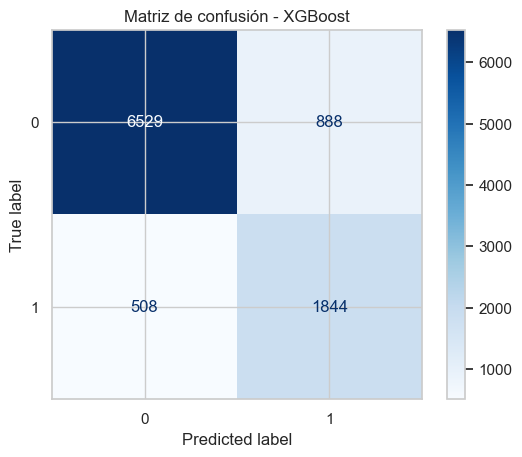


MODELO: Random Forest
Accuracy: 0.8358
ROC-AUC : 0.8894

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      7417
           1       0.65      0.69      0.67      2352

    accuracy                           0.84      9769
   macro avg       0.77      0.79      0.78      9769
weighted avg       0.84      0.84      0.84      9769



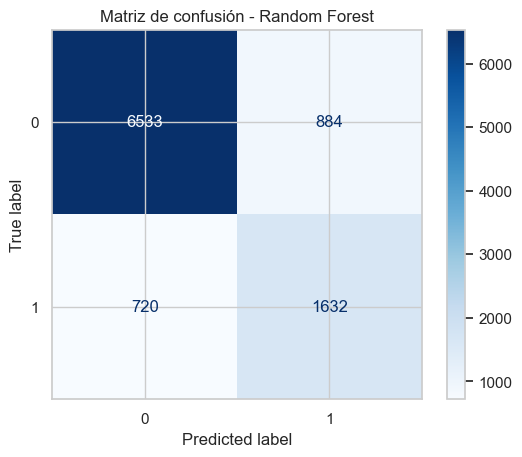


MODELO: Decision Tree
Accuracy: 0.8125
ROC-AUC : 0.7669

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      7417
           1       0.61      0.63      0.62      2352

    accuracy                           0.81      9769
   macro avg       0.74      0.75      0.75      9769
weighted avg       0.81      0.81      0.81      9769



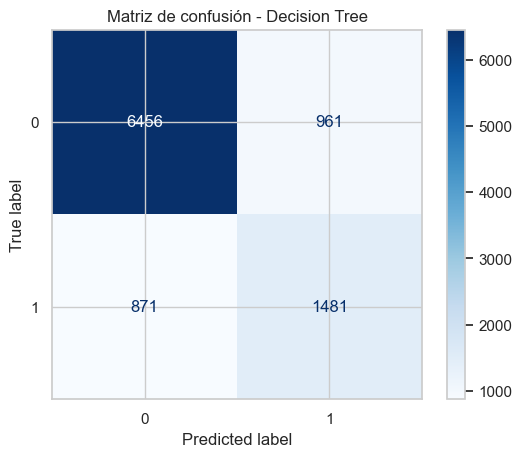

,Modelo,Accuracy,ROC_AUC,Precision_Clase_1,Recall_Clase_1,F1_Clase_1
0,XGBoost,0.8571,0.9234,0.6750,0.7840,0.7254
1,Random Forest,0.8358,0.8894,0.6486,0.6939,0.6705
2,Decision Tree,0.8125,0.7669,0.6065,0.6297,0.6179


In [92]:
resultados = []

for nombre, modelo in modelos.items():
    resultados.append(
        evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test)
    )

df_resultados = pd.DataFrame(resultados).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
display(df_resultados)


## 11. Ajuste de hiperparámetros de XGBoost

Una vez identificado XGBoost como el modelo más competitivo, se realiza una búsqueda de hiperparámetros con `GridSearchCV`.

La métrica de optimización elegida es `F1-score`, ya que en este problema interesa equilibrar precisión y recall de la clase positiva.


##### TUNING DE XGBOOST

In [95]:
param_grid = {
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1],
    "model__n_estimators": [100, 200]
}

grid_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid,
    scoring="f1",
    cv = 3,
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_xgb.best_params_)
print("\nMejor F1 en validación cruzada:")
print(round(grid_xgb.best_score_, 4))


Mejores parámetros:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

Mejor F1 en validación cruzada:
0.7089


##### Comparación XGB Base vs. Tuneado:

In [96]:
base_xgb = pipeline_xgb
tuned_xgb = grid_xgb.best_estimator_ 

comparacion_xgb = []

for nombre, modelo in {
    "XGBoost Base": base_xgb,
    "XGBoost Tuneado": tuned_xgb
}.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)

    comparacion_xgb.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Precision_Clase_1": report["1"]["precision"],
        "Recall_Clase_1": report["1"]["recall"],
        "F1_Clase_1": report["1"]["f1-score"]
    })

df_xgb_compare = pd.DataFrame(comparacion_xgb).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
display(df_xgb_compare)


,Modelo,Accuracy,ROC_AUC,Precision_Clase_1,Recall_Clase_1,F1_Clase_1
0,XGBoost Tuneado,0.8414,0.9235,0.6313,0.8206,0.7136
1,XGBoost Base,0.8571,0.9234,0.6750,0.7840,0.7254


## 12. Selección del modelo final

La comparación anterior permite decidir si se conserva el modelo base o el modelo tuneado.

En muchos casos, el modelo tuneado puede mejorar el `recall` de la clase positiva sin necesariamente mejorar el `ROC-AUC` o la exactitud global. Por ello, la selección final debe interpretarse como un trade-off entre desempeño general y capacidad de detección.

#### Selección del modelo final

In [102]:
base_row = df_xgb_compare[df_xgb_compare["Modelo"] == "XGBoost Base"].iloc[0]
tuned_row = df_xgb_compare[df_xgb_compare["Modelo"] == "XGBoost Tuneado"].iloc[0]

if tuned_row["ROC_AUC"] > base_row["ROC_AUC"]:
    final_model = tuned_xgb
    final_model_name = "XGBoost Tuneado"
    final_metrics = tuned_row
else:
    final_model = base_xgb
    final_model_name = "XGBoost Base"
    final_metrics = base_row

print("Modelo final seleccionado:", final_model_name)
display(final_metrics.to_frame("Valor"))


Modelo final seleccionado: XGBoost Tuneado


,Valor
Modelo,XGBoost Tuneado
Accuracy,0.8414
ROC_AUC,0.9235
Precision_Clase_1,0.6313
Recall_Clase_1,0.8206
F1_Clase_1,0.7136


## 13. Importancia de variables

Se analiza la importancia de variables del modelo final para identificar qué atributos aportan mayor capacidad predictiva.


In [103]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

df_importancia = (
    pd.DataFrame({
        "Variable": feature_names,
        "Importancia": importances
    })
    .sort_values("Importancia", ascending=False)
    .reset_index(drop=True)
)

display(df_importancia.head(15))


,Variable,Importancia
0,cat__marital-status_Married-civ-spouse,0.4248
1,num__education-num,0.0489
2,num__capital-gain,0.0404
3,cat__relationship_Own-child,0.0402
4,cat__occupation_Exec-managerial,0.0261
5,cat__occupation_Other-service,0.0253
6,cat__race_White,0.0211
7,num__hours-per-week,0.0211
8,cat__native-country_United-States,0.0205
9,num__age,0.0203


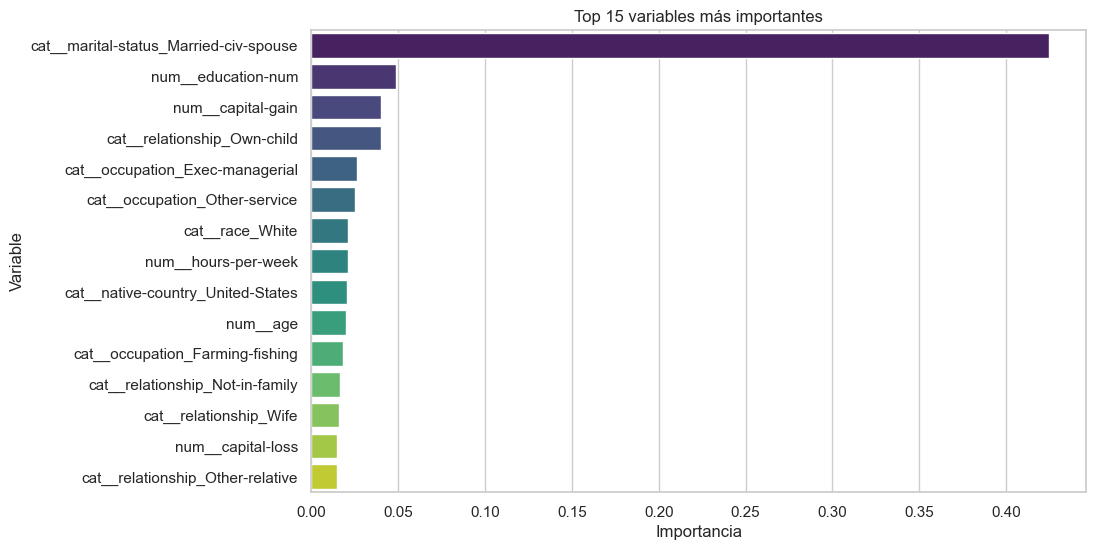

In [104]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancia.head(15),
    x="Importancia",
    y="Variable",
    hue="Variable",
    dodge=False,
    palette="viridis",
    legend=False
)
plt.title("Top 15 variables más importantes")
plt.show()


## 14. Resumen y conclusiones

La siguiente celda genera un resumen final utilizando los resultados reales obtenidos en la ejecución del notebook.


In [105]:
# =========================================
# 18. CONCLUSIONES AUTOMATICAS
# =========================================
top_features = (
    df_importancia.head(5)["Variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .tolist()
)

display(Markdown(f"""
## Conclusiones

El objetivo del proyecto fue predecir si una persona percibe ingresos anuales superiores a 50K utilizando variables sociodemográficas y laborales del dataset **Adult Census Income**.

A partir del análisis exploratorio, se observó que las variables numéricas con mayor asociación con la variable objetivo fueron **education-num**, **age**, **hours-per-week**, **capital-gain** y **capital-loss**. En las variables categóricas también se identificaron patrones relevantes en educación, ocupación, estado civil, relación familiar y sexo.

En la comparación de modelos, **XGBoost** obtuvo el mejor desempeño general frente a **Random Forest** y **Decision Tree**. Tras comparar la versión base y la versión ajustada, el modelo final seleccionado fue **{final_model_name}**.

### Métricas del modelo final
- Accuracy: **{final_metrics['Accuracy']:.3f}**
- ROC-AUC: **{final_metrics['ROC_AUC']:.3f}**
- Precision clase >50K: **{final_metrics['Precision_Clase_1']:.3f}**
- Recall clase >50K: **{final_metrics['Recall_Clase_1']:.3f}**
- F1-score clase >50K: **{final_metrics['F1_Clase_1']:.3f}**

### Variables más importantes
Las variables con mayor aporte predictivo en el modelo final fueron:
- **{top_features[0]}**
- **{top_features[1]}**
- **{top_features[2]}**
- **{top_features[3]}**
- **{top_features[4]}**

### Interpretación final
Los resultados sugieren que el ingreso está asociado a factores educativos, laborales y familiares. Sin embargo, estos hallazgos deben interpretarse como relaciones **predictivas** y no como relaciones **causales**.

### Limitaciones
- El dataset presenta desbalance de clases.
- Algunas categorías tienen pocos registros y pueden producir proporciones inestables.
- Variables sensibles como sexo, raza y país de origen requieren cautela por el posible riesgo de sesgo.

### Trabajo futuro
- Ajustar el umbral de clasificación según el objetivo del problema.
- Evaluar métricas de fairness entre grupos.
- Comparar con modelos más interpretables.
- Validar el modelo con datos externos o con validación más robusta.
"""))



## Conclusiones

El objetivo del proyecto fue predecir si una persona percibe ingresos anuales superiores a 50K utilizando variables sociodemográficas y laborales del dataset **Adult Census Income**.

A partir del análisis exploratorio, se observó que las variables numéricas con mayor asociación con la variable objetivo fueron **education-num**, **age**, **hours-per-week**, **capital-gain** y **capital-loss**. En las variables categóricas también se identificaron patrones relevantes en educación, ocupación, estado civil, relación familiar y sexo.

En la comparación de modelos, **XGBoost** obtuvo el mejor desempeño general frente a **Random Forest** y **Decision Tree**. Tras comparar la versión base y la versión ajustada, el modelo final seleccionado fue **XGBoost Tuneado**.

### Métricas del modelo final
- Accuracy: **0.841**
- ROC-AUC: **0.924**
- Precision clase >50K: **0.631**
- Recall clase >50K: **0.821**
- F1-score clase >50K: **0.714**

### Variables más importantes
Las variables con mayor aporte predictivo en el modelo final fueron:
- **marital-status_Married-civ-spouse**
- **education-num**
- **capital-gain**
- **relationship_Own-child**
- **occupation_Exec-managerial**

### Interpretación final
Los resultados sugieren que el ingreso está asociado a factores educativos, laborales y familiares. Sin embargo, estos hallazgos deben interpretarse como relaciones **predictivas** y no como relaciones **causales**.

### Limitaciones
- El dataset presenta desbalance de clases.
- Algunas categorías tienen pocos registros y pueden producir proporciones inestables.
- Variables sensibles como sexo, raza y país de origen requieren cautela por el posible riesgo de sesgo.

### Trabajo futuro
- Ajustar el umbral de clasificación según el objetivo del problema.
- Evaluar métricas de fairness entre grupos.
- Comparar con modelos más interpretables.
- Validar el modelo con datos externos o con validación más robusta.
